# Embeddings Lab

- [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W4/M3/lessons/02_embeddings.ipynb)

In this tutorial, you will use the OpenRouter API's embedding endpoint (OpenAI-compatible) to explore similarity scores.

## Environment Setup

### Environment variables

The following environment variables are used in this notebook:

| Variable               | Required | Purpose                                  |
|------------------------|----------|------------------------------------------|
| `OPENROUTER_API_KEY`   | Yes      | Authenticates requests to OpenRouter LLMs |

#### On Colab?

Store these as Colab **Secrets** (key icon in the left sidebar), using the variable names above (for example `OPENROUTER_API_KEY`). Grant this notebook access to the secrets so they can be read securely at runtime.

#### Locally?

Store these in a `.env` file in your project directory (which should be listed in `.gitignore` so it is never committed). The code below uses `python-dotenv` to load values from this file into environment variables at runtime.


::: {.callout-warning}

API Keys are secrets and thus [**shall never be exposed**](./never_expose_api_keys.qmd).

:::

### Reading environment variables in

In [38]:
import os

In [39]:
try:
    # In Colab? read from userdata (secrets)
    from google.colab import userdata
    ON_COLAB = True
    os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
except ImportError:
    # Load `.env` file (locally)
    from dotenv import load_dotenv
    load_dotenv(override=True)

## Select Embedding Model

* See [embedding models](https://openrouter.ai/models?fmt=cards&output_modalities=embeddings) on OpenRouter.ai
* And [OpenRouter Embeddings API](https://openrouter.ai/docs/api-reference/embeddings) on how to use them

In [40]:
# https://openrouter.ai/docs/api/reference/embeddings
import requests

model_name = "nvidia/llama-nemotron-embed-vl-1b-v2:free"
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")

def embed(texts: list[str]):
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": model_name,
            "input": texts,
        },
    )
    data = response.json()
    return data["data"]

## Calculate similarity scores

This example embeds some variations on the pangram, `The quick brown fox jumps over the lazy dog`, including spelling mistakes and shortenings of the phrase. Another pangram and a somewhat unrelated phrase have been included for comparison.

In [41]:
texts = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick rbown fox jumps over the lazy dog.',
    'teh fast fox jumps over the slow woofer.',
    'a quick brown fox jmps over lazy dog.',
    'brown fox jumping over dog',
    'fox > dog',
    # Alternative pangram for comparison:
    'The five boxing wizards jump quickly.',
    # Unrelated text, also for comparison:
    'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus.',
    # Arabic texts
    "يقفز الثعلب البني السريع فوق الكلب الكسول.",
    "التعليم هو مفتاح التقدم.",
    "السلام عليكم ورحمة الله وبركاته.",
    "اللغة العربية لغة غنية وجميلة."
]

In [42]:
embeddings = embed(texts)

In [43]:
print("Count:", len(embeddings))
print("Dimensions (Size):", len(embeddings[0]["embedding"]))

Count: 12
Dimensions (Size): 2048


Define a short helper function that will make it easier to display longer embedding texts in our visualisation.

In [44]:
def truncate(t: str, limit: int = 50) -> str:
    """Truncate labels to fit on the chart."""
    if len(t) > limit:
        return t[:limit-3] + '...'
    else:
        return t

truncated_texts = [truncate(t) for t in texts]

A similarity score of two embedding vectors can be obtained by calculating their inner product. If $\mathbf{u}$ is the first embedding vector, and $\mathbf{v}$ the second, this is $\mathbf{u}^T \mathbf{v}$. As the API provides embedding vectors that are normalised to unit length, this is also the **cosine similarity**.

This score can be computed across all embeddings through the matrix self-multiplication: `df @ df.T`.

Note that the range from 0.0 (completely dissimilar) to 1.0 (completely similar) is depicted in the heatmap from light (0.0) to dark (1.0).

In [45]:
# %pip install -U -q pandas seaborn matplotlib

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# Set up the embeddings in a dataframe.
df = pd.DataFrame([e["embedding"] for e in embeddings], index=truncated_texts)

# Perform the similarity calculation
sim = df @ df.T

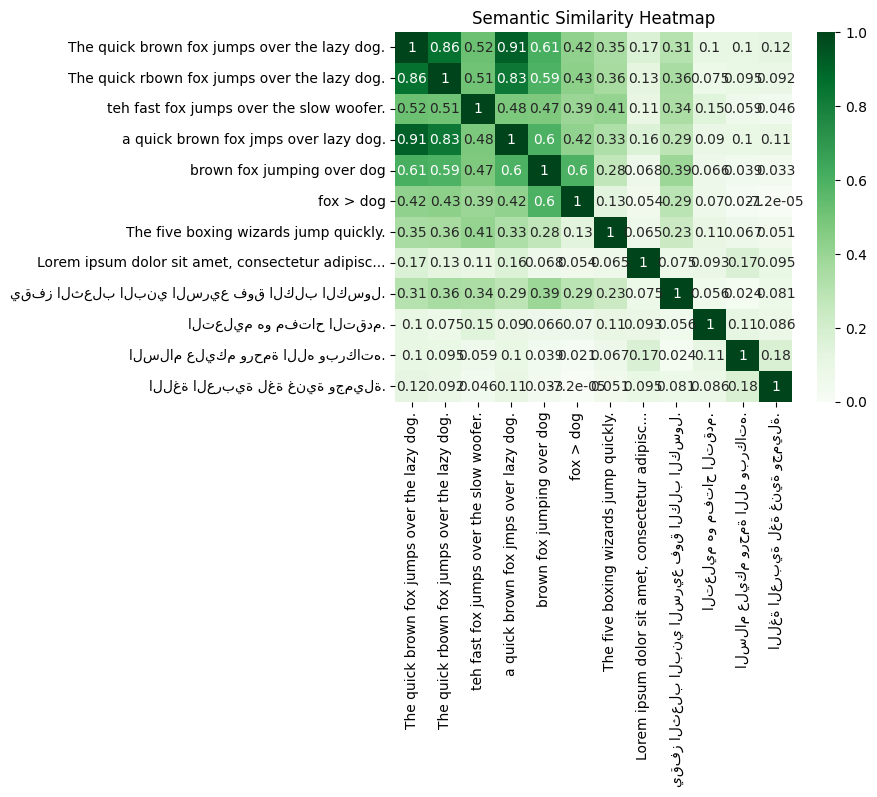

In [48]:
# Draw!
# plt.figure(figsize=(10, 8))
sns.heatmap(sim, annot=True, vmin=0, vmax=1, cmap="Greens")
plt.title("Semantic Similarity Heatmap")
plt.show()

You can see the scores for a particular term directly by looking it up in the dataframe.

In [49]:
print(sim['The quick brown fox jumps over the lazy dog.'].sort_values(ascending=False))

The quick brown fox jumps over the lazy dog.          1.000861
a quick brown fox jmps over lazy dog.                 0.911227
The quick rbown fox jumps over the lazy dog.          0.855384
brown fox jumping over dog                            0.608608
teh fast fox jumps over the slow woofer.              0.521211
fox > dog                                             0.421878
The five boxing wizards jump quickly.                 0.350881
يقفز الثعلب البني السريع فوق الكلب الكسول.            0.307906
Lorem ipsum dolor sit amet, consectetur adipisc...    0.170421
اللغة العربية لغة غنية وجميلة.                        0.123573
السلام عليكم ورحمة الله وبركاته.                      0.103363
التعليم هو مفتاح التقدم.                              0.103237
Name: The quick brown fox jumps over the lazy dog., dtype: float64


## Further reading


* [OpenAI embeddings documentation](https://platform.openai.com/docs/guides/embeddings) and [similarity search use cases](https://platform.openai.com/docs/guides/embeddings/use-cases)